# Lab 1: Classical NLP Techniques

**Part 1 — Natural Language Processing Fundamentals**

**Author:** Bassem Ben Hamed | **Date:** February 2026

---

## Objectives

In this lab, you will:

1. **Load and explore** the 20 Newsgroups dataset
2. **Preprocess and tokenize** raw text data
3. **Build a TF-IDF-based text classifier** and evaluate its performance
4. **Train Word2Vec embeddings** on the corpus
5. **Explore word similarities and analogies** in vector space
6. **Compare classical methods** (BoW, TF-IDF, Word2Vec) on a classification task

## Tools

- **Python 3.10+**
- **NLTK** — tokenization, stopwords, stemming
- **scikit-learn** — TF-IDF, classification, evaluation
- **Gensim** — Word2Vec training and exploration
- **Matplotlib / Seaborn** — visualization

---

## 0. Environment Setup

Install the required libraries (run once):

In [1]:
!pip install nltk scikit-learn gensim matplotlib seaborn numpy pandas

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---

## 1. Loading and Exploring the Dataset

### About 20 Newsgroups

The **20 Newsgroups** dataset is a collection of approximately **18,000 newsgroup posts**, partitioned across **20 different topics**. It is a standard benchmark for text classification and clustering.

The categories are organized into broad themes:

| Theme | Categories |
|-------|------------|
| **Computers** | comp.graphics, comp.os.ms-windows.misc, comp.sys.ibm.pc.hardware, comp.sys.mac.hardware, comp.windows.x |
| **Science** | sci.crypt, sci.electronics, sci.med, sci.space |
| **Politics** | talk.politics.misc, talk.politics.guns, talk.politics.mideast |
| **Religion** | alt.atheism, soc.religion.christian, talk.religion.misc |
| **Recreation** | rec.autos, rec.motorcycles, rec.sport.baseball, rec.sport.hockey |
| **Misc** | misc.forsale |

In [3]:
# Load the dataset (remove headers, footers, quotes to avoid data leakage)
newsgroups_train = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

print(f'Training samples: {len(newsgroups_train.data)}')
print(f'Test samples:     {len(newsgroups_test.data)}')
print(f'Number of classes: {len(newsgroups_train.target_names)}')
print(f'\nClass names:\n')
for i, name in enumerate(newsgroups_train.target_names):
    print(f'  {i:2d} — {name}')

Training samples: 11314
Test samples:     7532
Number of classes: 20

Class names:

   0 — alt.atheism
   1 — comp.graphics
   2 — comp.os.ms-windows.misc
   3 — comp.sys.ibm.pc.hardware
   4 — comp.sys.mac.hardware
   5 — comp.windows.x
   6 — misc.forsale
   7 — rec.autos
   8 — rec.motorcycles
   9 — rec.sport.baseball
  10 — rec.sport.hockey
  11 — sci.crypt
  12 — sci.electronics
  13 — sci.med
  14 — sci.space
  15 — soc.religion.christian
  16 — talk.politics.guns
  17 — talk.politics.mideast
  18 — talk.politics.misc
  19 — talk.religion.misc


| Option      | What it removes                                                                    |
| ----------- | ---------------------------------------------------------------------------------- |
| **headers** | Email/news headers (e.g., From, Subject, Date, etc.)                               |
| **footers** | Signatures or endings of messages (names, contact info, signatures)                |
| **quotes**  | Quoted text from previous messages (lines starting with `>` often used in replies) |


In [5]:
# Look at a sample document
idx = 42
print(f'Category: {newsgroups_train.target_names[newsgroups_train.target[idx]]}')
print(f'Label index: {newsgroups_train.target[idx]}')
print(f'\n--- Document (first 100 chars) ---\n')
print(newsgroups_train.data[idx][:100])

Category: comp.sys.ibm.pc.hardware
Label index: 3

--- Document (first 100 chars) ---

Western Digital 1-800-832-4778.....Sam


In [6]:
# Sauvegarder le dataset en CSV
import os
DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

train_csv_path = os.path.join(DATA_DIR, 'newsgroups_train.csv')
test_csv_path = os.path.join(DATA_DIR, 'newsgroups_test.csv')

df_train = pd.DataFrame({
    'text': newsgroups_train.data,
    'label': newsgroups_train.target,
    'category': [newsgroups_train.target_names[t] for t in newsgroups_train.target]
})

df_test = pd.DataFrame({
    'text': newsgroups_test.data,
    'label': newsgroups_test.target,
    'category': [newsgroups_test.target_names[t] for t in newsgroups_test.target]
})

df_train.to_csv(train_csv_path, index=False)
df_test.to_csv(test_csv_path, index=False)

print(f"CSV sauvegardés:")
print(f"  - {train_csv_path}")
print(f"  - {test_csv_path}")
print(f"  - {len(df_train)} training samples")
print(f"  - {len(df_test)} test samples")

CSV sauvegardés:
  - ../data/newsgroups_train.csv
  - ../data/newsgroups_test.csv
  - 11314 training samples
  - 7532 test samples


In [6]:
# Charger le dataset depuis le CSV sauvegardé et explorer
print("=== Chargement depuis CSV local ===\n")

df_train_loaded = pd.read_csv(train_csv_path)
df_test_loaded = pd.read_csv(test_csv_path)

print(f"Training DataFrame: {df_train_loaded.shape}")
print(f"Test DataFrame: {df_test_loaded.shape}")

print("\n--- Aperçu du Training DataFrame (5 premières lignes) ---")
display(df_train_loaded.head())

print("\n--- Colonnes disponibles ---")
print(df_train_loaded.columns.tolist())

print("\n--- Types de données ---")
print(df_train_loaded.dtypes)

print("\n--- Distribution des catégories ---")
print(df_train_loaded['category'].value_counts())

=== Chargement depuis CSV local ===

Training DataFrame: (11314, 3)
Test DataFrame: (7532, 3)

--- Aperçu du Training DataFrame (5 premières lignes) ---


,text,label,category
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space



--- Colonnes disponibles ---
['text', 'label', 'category']

--- Types de données ---
text        object
label        int64
category    object
dtype: object

--- Distribution des catégories ---
category
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
comp.windows.x              593
sci.space                   593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [7]:
# Charger le dataset depuis le CSV sauvegardé et explorer
print("=== Chargement depuis CSV local ===\n")

df_train_loaded = pd.read_csv(train_csv_path)
df_test_loaded = pd.read_csv(test_csv_path)

print(f"Training DataFrame: {df_train_loaded.shape}")
print(f"Test DataFrame: {df_test_loaded.shape}")

print("\n--- Aperçu du Training DataFrame (5 premières lignes) ---")
display(df_train_loaded.head())

print("\n--- Colonnes disponibles ---")
print(df_train_loaded.columns.tolist())

print("\n--- Types de données ---")
print(df_train_loaded.dtypes)

print("\n--- Distribution des catégories ---")
print(df_train_loaded['category'].value_counts())

=== Chargement depuis CSV local ===

Training DataFrame: (11314, 3)
Test DataFrame: (7532, 3)

--- Aperçu du Training DataFrame (5 premières lignes) ---


,text,label,category
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space



--- Colonnes disponibles ---
['text', 'label', 'category']

--- Types de données ---
text        object
label        int64
category    object
dtype: object

--- Distribution des catégories ---
category
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
comp.windows.x              593
sci.space                   593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


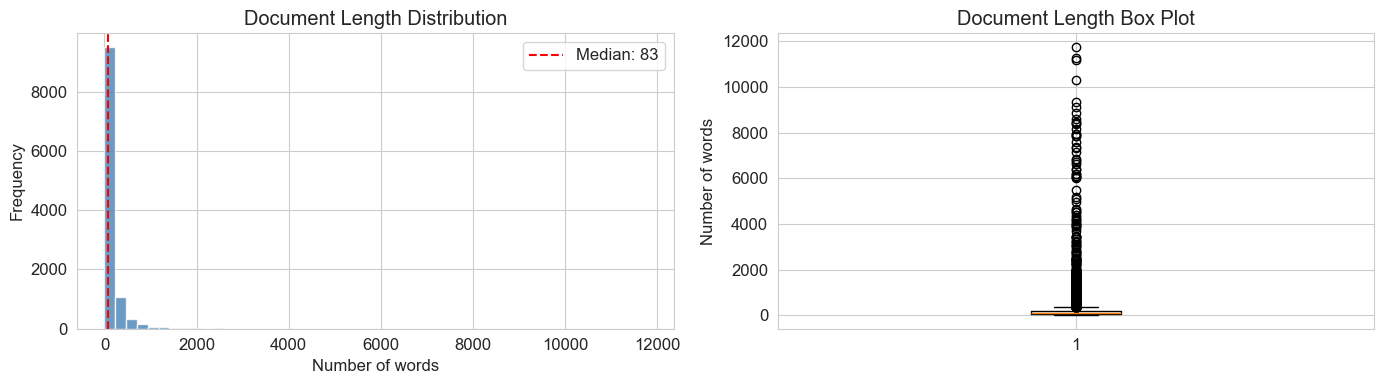

Mean length:   185.8 words
Median length: 83.0 words
Max length:    11765 words
Min length:    0 words
Empty docs:    300


In [8]:
# Document length distribution
train_lengths = [len(doc.split()) for doc in newsgroups_train.data]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Document Length Distribution')
axes[0].axvline(np.median(train_lengths), color='red', linestyle='--',
                label=f'Median: {np.median(train_lengths):.0f}')
axes[0].legend()

axes[1].boxplot(train_lengths, vert=True)
axes[1].set_ylabel('Number of words')
axes[1].set_title('Document Length Box Plot')

plt.tight_layout()
plt.show()

print(f'Mean length:   {np.mean(train_lengths):.1f} words')
print(f'Median length: {np.median(train_lengths):.1f} words')
print(f'Max length:    {np.max(train_lengths)} words')
print(f'Min length:    {np.min(train_lengths)} words')
print(f'Empty docs:    {sum(1 for l in train_lengths if l == 0)}')

---

## 2. Text Preprocessing and Tokenization

### 2.1 Why Preprocess?

Raw text is noisy and inconsistent. Preprocessing transforms it into a **clean, standardized form** that models can exploit more effectively.

### 2.2 Tokenization

**Tokenization** splits text into individual units (tokens). There are multiple granularity levels:

| Level | Example | Pros | Cons |
|-------|---------|------|------|
| **Word-level** | `"I love NLP"` → `["I", "love", "NLP"]` | Intuitive | Large vocab, OOV |
| **Character-level** | `"NLP"` → `["N", "L", "P"]` | Small vocab | Long sequences |
| **Sentence-level** | Split paragraphs into sentences | Structural | Ambiguity with abbreviations |

### 2.3 Stopwords

**Stopwords** are high-frequency words ("the", "is", "at") that carry little semantic meaning. Removing them reduces dimensionality and noise.

### 2.4 Stemming vs. Lemmatization

Both reduce words to a base form, but differently:

- **Stemming** (Porter, Snowball): crude rule-based suffix stripping  
  `"running"` → `"run"`, `"better"` → `"better"` (no change), `"studies"` → `"studi"`

- **Lemmatization** (WordNet): dictionary-based, returns valid words  
  `"running"` → `"run"`, `"better"` → `"good"`, `"studies"` → `"study"`

In [9]:
# --- Tokenization demo ---
sample_text = newsgroups_train.data[42]
print('=== Original text (first 300 chars) ===')
print(sample_text[:300])
print()

=== Original text (first 300 chars) ===
Western Digital 1-800-832-4778.....Sam



In [10]:
# Word tokenization with NLTK
tokens = word_tokenize(sample_text)
print(f'Number of tokens: {len(tokens)}')
print(f'First 30 tokens: {tokens[:30]}')

Number of tokens: 5
First 30 tokens: ['Western', 'Digital', '1-800-832-4778', '.....', 'Sam']


In [11]:
# Sentence tokenization
sentences = sent_tokenize(sample_text)
print(f'Number of sentences: {len(sentences)}')
for i, sent in enumerate(sentences[:5]):
    print(f'  [{i}] {sent[:100]}...' if len(sent) > 100 else f'  [{i}] {sent}')

Number of sentences: 1
  [0] Western Digital 1-800-832-4778.....Sam


In [12]:
# --- Stopword removal ---
stop_words = set(stopwords.words('english'))

print(f'Number of English stopwords: {len(stop_words)}')
print(f'Examples: {sorted(list(stop_words))[:20]}')

# Filter tokens
tokens_lower = [t.lower() for t in tokens]
tokens_no_stop = [t for t in tokens_lower if t not in stop_words and t.isalpha()]

print(f'\nBefore stopword removal: {len(tokens_lower)} tokens')
print(f'After stopword removal:  {len(tokens_no_stop)} tokens')
print(f'Removed: {len(tokens_lower) - len(tokens_no_stop)} tokens ({100*(len(tokens_lower)-len(tokens_no_stop))/len(tokens_lower):.1f}%)')

Number of English stopwords: 198
Examples: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

Before stopword removal: 5 tokens
After stopword removal:  3 tokens
Removed: 2 tokens (40.0%)


In [13]:
# --- Stemming vs Lemmatization ---
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

demo_words = ['running', 'better', 'studies', 'computed', 'happily',
              'geese', 'wolves', 'universities', 'flying', 'organization']

comparison = pd.DataFrame({
    'Original': demo_words,
    'Stemmed': [stemmer.stem(w) for w in demo_words],
    'Lemmatized': [lemmatizer.lemmatize(w) for w in demo_words]
})

print(comparison.to_string(index=False))

    Original Stemmed   Lemmatized
     running     run      running
      better  better       better
     studies   studi        study
    computed  comput     computed
     happily happili      happily
       geese    gees        goose
      wolves    wolv         wolf
universities univers   university
      flying     fli       flying
organization   organ organization


In [14]:
# --- Full preprocessing pipeline ---
import re

def preprocess_text(text, use_lemma=True):
    """Full preprocessing pipeline for a single document."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Tokenize
    tokens = text.split()
    # 4. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 5. Stemming or Lemmatization
    if use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# Demo
sample_processed = preprocess_text(newsgroups_train.data[42])
print(f'Processed tokens (first 30): {sample_processed[:30]}')

Processed tokens (first 30): ['western', 'digital', 'sam']


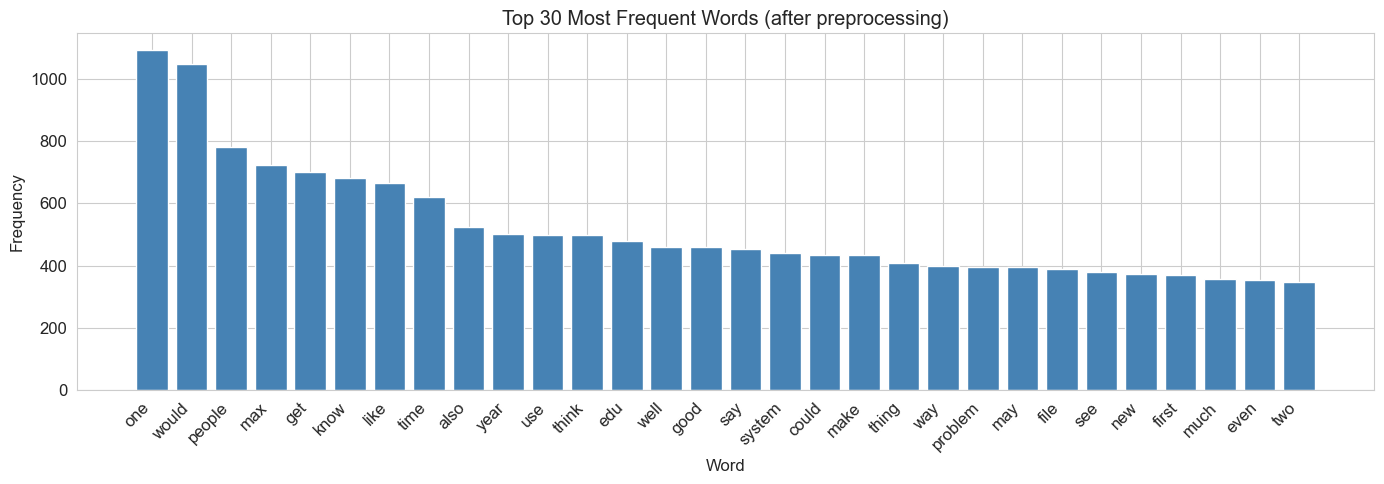

Total tokens: 187,136
Unique tokens: 26,552


In [15]:
# Word frequency analysis after preprocessing
from collections import Counter

# Process a sample of documents
all_tokens = []
for doc in newsgroups_train.data[:2000]:
    all_tokens.extend(preprocess_text(doc))

freq = Counter(all_tokens)
top_30 = freq.most_common(30)

words, counts = zip(*top_30)

plt.figure(figsize=(14, 5))
plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top 30 Most Frequent Words (after preprocessing)')
plt.tight_layout()
plt.show()

print(f'Total tokens: {len(all_tokens):,}')
print(f'Unique tokens: {len(freq):,}')

---

## 3. Bag-of-Words and TF-IDF Representations

### 3.1 Bag-of-Words (BoW)

The **Bag-of-Words** model represents each document as a **word frequency vector**, ignoring word order.

Given a vocabulary $V = \{w_1, w_2, \ldots, w_{|V|}\}$, a document $d$ is represented as:

$$\vec{d} = \big[\text{count}(w_1, d),\; \text{count}(w_2, d),\; \ldots,\; \text{count}(w_{|V|}, d)\big]$$

**Properties:**
- Simple and interpretable
- Ignores word order ("dog bites man" = "man bites dog")
- High-dimensional and sparse

### 3.2 TF-IDF (Term Frequency — Inverse Document Frequency)

TF-IDF addresses the limitation of raw word counts by weighting words according to their **importance** in a document relative to the corpus.

#### Term Frequency (TF)

How often a term $t$ appears in document $d$:

$$\text{tf}(t, d) = \frac{\text{count}(t, d)}{\sum_{t' \in d} \text{count}(t', d)}$$

#### Inverse Document Frequency (IDF)

How rare or common a term is across the **entire corpus** of $N$ documents:

$$\text{idf}(t) = \log \frac{N}{\text{df}(t)}$$

where $\text{df}(t)$ = number of documents containing term $t$.

> **Intuition:** Words appearing in many documents (e.g., "the") get a **low IDF**, while rare, distinctive words get a **high IDF**.

#### TF-IDF Score

$$\text{tfidf}(t, d) = \text{tf}(t, d) \times \text{idf}(t)$$

**scikit-learn's formula** (with smoothing):

$$\text{idf}(t) = \log \frac{1 + N}{1 + \text{df}(t)} + 1$$

The resulting vectors are then L2-normalized.

In [16]:
# --- Bag-of-Words ---
bow_vectorizer = CountVectorizer(
    max_features=10000,
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_bow = bow_vectorizer.fit_transform(newsgroups_train.data)
X_test_bow = bow_vectorizer.transform(newsgroups_test.data)

print(f'BoW matrix shape (train): {X_train_bow.shape}')
print(f'BoW matrix shape (test):  {X_test_bow.shape}')
print(f'Vocabulary size: {len(bow_vectorizer.vocabulary_)}')
print(f'Sparsity: {1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.4%}')

BoW matrix shape (train): (11314, 10000)
BoW matrix shape (test):  (7532, 10000)
Vocabulary size: 10000
Sparsity: 99.4875%


In [17]:
# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    min_df=2,
    max_df=0.95,
    sublinear_tf=True   # apply log(1 + tf) instead of raw tf
)

X_train_tfidf = tfidf_vectorizer.fit_transform(newsgroups_train.data)
X_test_tfidf = tfidf_vectorizer.transform(newsgroups_test.data)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test):  {X_test_tfidf.shape}')

TF-IDF matrix shape (train): (11314, 10000)
TF-IDF matrix shape (test):  (7532, 10000)


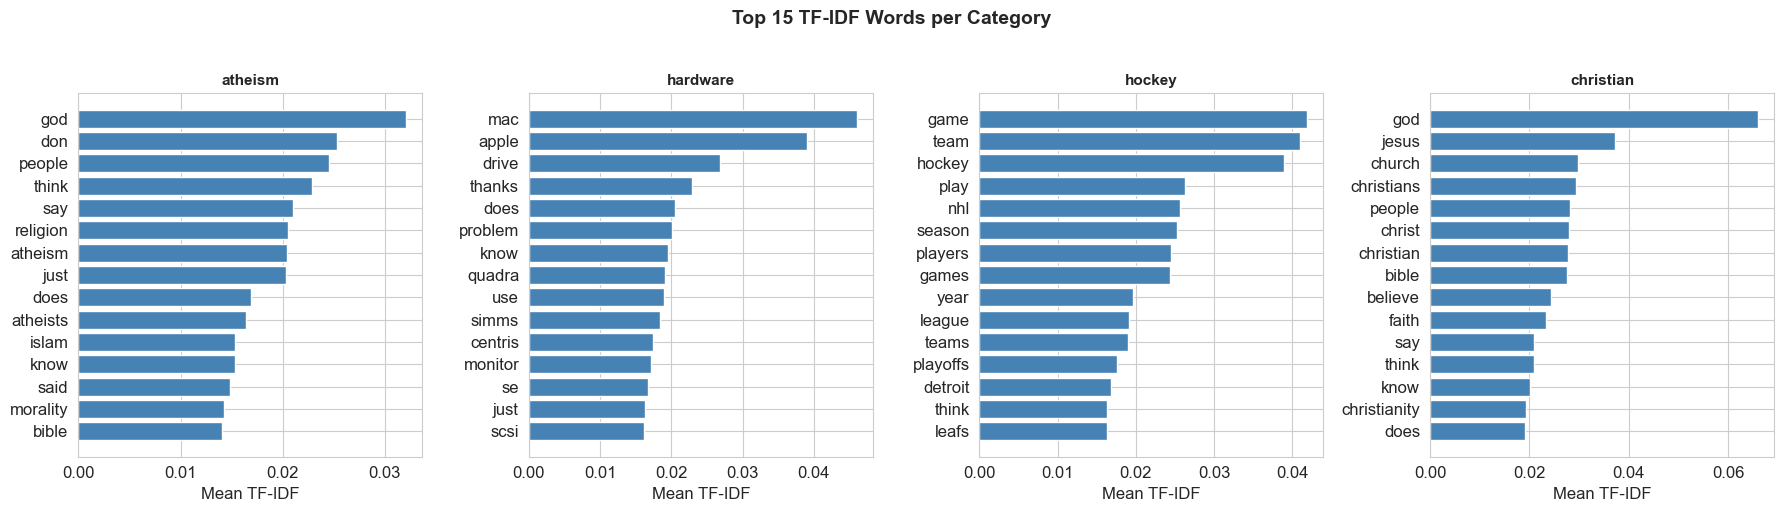

In [18]:
# Visualize TF-IDF: top words per category
feature_names = tfidf_vectorizer.get_feature_names_out()

# Pick 4 diverse categories
categories_to_show = [0, 4, 10, 15]  # alt.atheism, comp.windows.x, rec.sport.hockey, sci.space

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, cat_idx in zip(axes, categories_to_show):
    # Get documents for this category
    mask = newsgroups_train.target == cat_idx
    cat_tfidf = X_train_tfidf[mask].mean(axis=0).A1  # mean TF-IDF per word
    top_indices = cat_tfidf.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [cat_tfidf[i] for i in top_indices]

    ax.barh(top_words[::-1], top_scores[::-1], color='steelblue')
    ax.set_title(newsgroups_train.target_names[cat_idx].split('.')[-1],
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF')

plt.suptitle('Top 15 TF-IDF Words per Category', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Text Classification with TF-IDF

### 4.1 Classifiers Overview

We will compare three classical classifiers on TF-IDF features:

#### Multinomial Naive Bayes

Based on **Bayes' theorem**, assumes feature independence:

$$P(y \mid \vec{x}) = \frac{P(\vec{x} \mid y) \cdot P(y)}{P(\vec{x})} \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

Fast and works well with sparse, high-dimensional data like TF-IDF.

#### Logistic Regression

Models the probability of class $k$ using the **softmax function** (multinomial case):

$$P(y = k \mid \vec{x}) = \frac{e^{\vec{w}_k^T \vec{x} + b_k}}{\sum_{j=1}^{K} e^{\vec{w}_j^T \vec{x} + b_j}}$$

Trained by minimizing the **cross-entropy loss**:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log \hat{y}_{ik}$$

#### Linear SVM (Support Vector Machine)

Finds the **hyperplane** that maximizes the margin between classes:

$$\min_{\vec{w}, b} \frac{1}{2} \|\vec{w}\|^2 + C \sum_{i=1}^{N} \max(0, 1 - y_i(\vec{w}^T \vec{x}_i + b))$$

The second term is the **hinge loss** — penalizes misclassified or marginal samples.

### 4.2 Evaluation Metrics Reminder

For multi-class classification:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | $\frac{\text{correct}}{\text{total}}$ | Overall correctness |
| **Precision** | $\frac{TP}{TP + FP}$ | Of predicted positives, how many are correct? |
| **Recall** | $\frac{TP}{TP + FN}$ | Of actual positives, how many are found? |
| **F1-Score** | $2 \cdot \frac{P \times R}{P + R}$ | Harmonic mean of Precision and Recall |

For multi-class, we use **macro-average** (average per class) or **weighted-average** (weighted by class frequency).

In [19]:
# --- Train and evaluate classifiers ---
y_train = newsgroups_train.target
y_test = newsgroups_test.target

classifiers = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42),
}

results = {}

for name, clf in classifiers.items():
    # Train
    clf.fit(X_train_tfidf, y_train)
    # Predict
    y_pred = clf.predict(X_test_tfidf)
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f'{name:25s} — Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}')

print('\n--- Results Summary ---')
results_df = pd.DataFrame(results).T
results_df

Naive Bayes               — Accuracy: 0.6799  Precision: 0.6854  Recall: 0.6799  F1: 0.6737
Logistic Regression       — Accuracy: 0.6723  Precision: 0.6785  Recall: 0.6723  F1: 0.6718
Linear SVM                — Accuracy: 0.6670  Precision: 0.6709  Recall: 0.6670  F1: 0.6657

--- Results Summary ---


,Accuracy,Precision,Recall,F1
Naive Bayes,0.679899,0.685411,0.679899,0.673669
Logistic Regression,0.672331,0.678517,0.672331,0.671770
Linear SVM,0.667021,0.670899,0.667021,0.665732


In [20]:
# Detailed classification report for the best model (Naive Bayes in this case)
best_clf = classifiers['Naive Bayes'] 
y_pred_best = best_clf.predict(X_test_tfidf)

print('=== Classification Report — Naive Bayes  + TF-IDF ===\n')
print(classification_report(y_test, y_pred_best,
                            target_names=newsgroups_test.target_names))

=== Classification Report — Naive Bayes  + TF-IDF ===

                          precision    recall  f1-score   support

             alt.atheism       0.50      0.42      0.46       319
           comp.graphics       0.60      0.70      0.65       389
 comp.os.ms-windows.misc       0.65      0.52      0.57       394
comp.sys.ibm.pc.hardware       0.58      0.66      0.62       392
   comp.sys.mac.hardware       0.71      0.63      0.67       385
          comp.windows.x       0.79      0.76      0.77       395
            misc.forsale       0.79      0.77      0.78       390
               rec.autos       0.73      0.69      0.71       396
         rec.motorcycles       0.75      0.75      0.75       398
      rec.sport.baseball       0.87      0.80      0.83       397
        rec.sport.hockey       0.58      0.92      0.71       399
               sci.crypt       0.79      0.73      0.76       396
         sci.electronics       0.64      0.54      0.59       393
                 sci

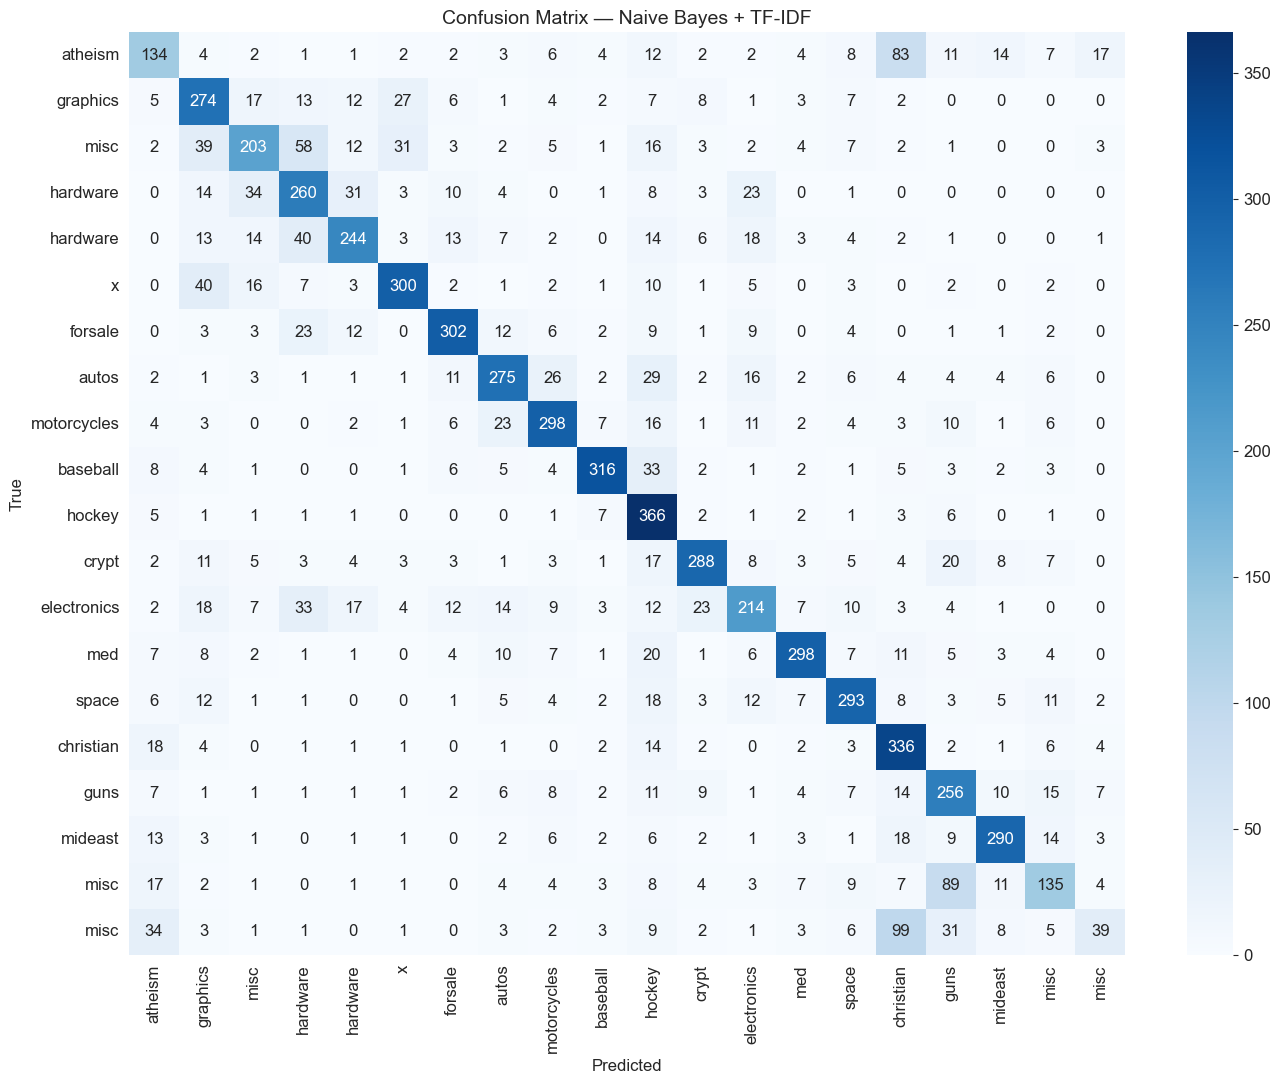

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
short_names = [n.split('.')[-1] for n in newsgroups_test.target_names]

plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix — Naive Bayes + TF-IDF', fontsize=14)
plt.tight_layout()
plt.show()

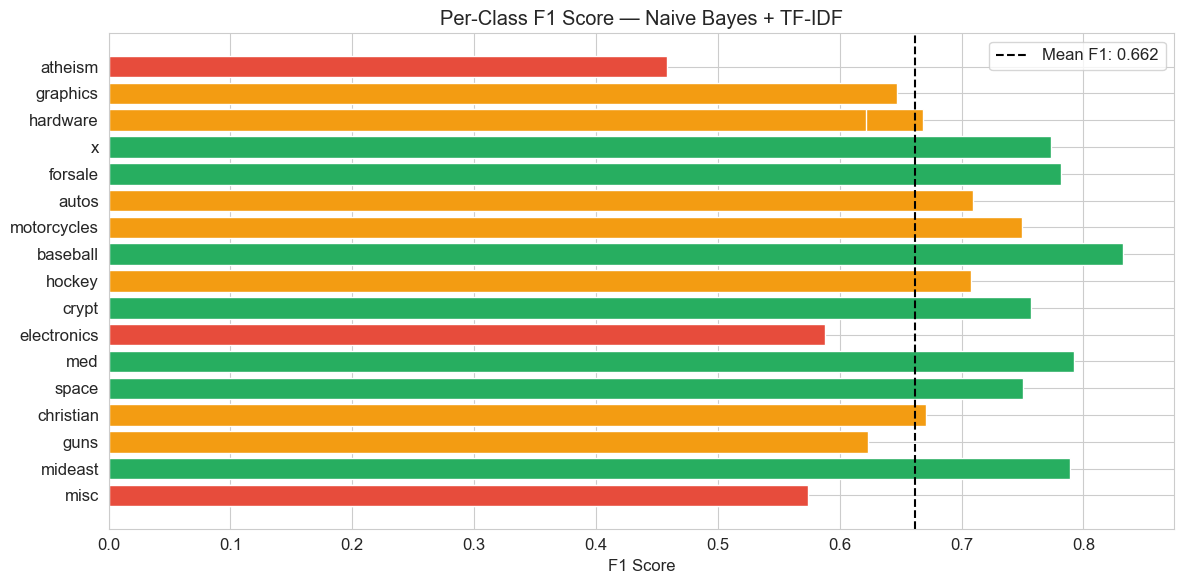


Hardest categories (lowest F1):
  talk.religion.misc                  F1 = 0.236
  alt.atheism                         F1 = 0.458
  talk.politics.misc                  F1 = 0.506
  comp.os.ms-windows.misc             F1 = 0.574
  sci.electronics                     F1 = 0.588


In [22]:
# Per-class F1 score visualization
from sklearn.metrics import f1_score as f1_per_class

f1_per = f1_score(y_test, y_pred_best, average=None)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if f < 0.6 else '#f39c12' if f < 0.75 else '#27ae60' for f in f1_per]
plt.barh(short_names[::-1], f1_per[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('F1 Score')
plt.title('Per-Class F1 Score — Naive Bayes + TF-IDF')
plt.axvline(x=np.mean(f1_per), color='black', linestyle='--',
            label=f'Mean F1: {np.mean(f1_per):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

# Identify hardest categories
print('\nHardest categories (lowest F1):')
for idx in np.argsort(f1_per)[:5]:
    print(f'  {newsgroups_test.target_names[idx]:35s} F1 = {f1_per[idx]:.3f}')

### 4.3 Analysis

**Observations:**
- Categories like `talk.religion.misc` and `talk.politics.misc` are harder — they share vocabulary with similar categories.
- Technical categories (`comp.*`, `sci.*`) tend to have more distinctive vocabulary → higher F1.
- The confusion matrix reveals common confusions (e.g., religion categories mixing with each other).

---

## 5. Word2Vec: Training Word Embeddings

### 5.1 Theory Recap

**Word2Vec** (Mikolov et al., 2013) learns **dense vector representations** of words from their context.

#### Key Idea

> *"You shall know a word by the company it keeps."* — J.R. Firth, 1957

#### Two Architectures

**Skip-gram** — predict context words given a target word:

$$\max \frac{1}{T} \sum_{t=1}^{T} \sum_{-c \le j \le c,\, j \ne 0} \log P(w_{t+j} \mid w_t)$$

where $c$ is the context window size and $T$ is the total number of words.

The probability is modeled with **softmax**:

$$P(w_O \mid w_I) = \frac{\exp(\vec{v}'_{w_O}{}^T \vec{v}_{w_I})}{\sum_{w=1}^{W} \exp(\vec{v}'_w{}^T \vec{v}_{w_I})}$$

where $\vec{v}_w$ and $\vec{v}'_w$ are the input and output vector representations.

**CBOW** (Continuous Bag-of-Words) — predict the target word given context words:

$$\max \frac{1}{T} \sum_{t=1}^{T} \log P\big(w_t \mid w_{t-c}, \ldots, w_{t-1}, w_{t+1}, \ldots, w_{t+c}\big)$$

#### Hyperparameters

| Parameter | Description | Typical values |
|-----------|-------------|----------------|
| `vector_size` | Dimensionality of embeddings | 100–300 |
| `window` | Context window size | 5–10 |
| `min_count` | Ignore words with freq < this | 2–5 |
| `sg` | 0 = CBOW, 1 = Skip-gram | 1 (skip-gram) |
| `epochs` | Number of training passes | 5–20 |
| `negative` | Number of negative samples | 5–15 |

In [23]:
# --- Prepare corpus for Word2Vec ---
# Gensim expects a list of tokenized sentences

def tokenize_for_w2v(text):
    """Light tokenization for Word2Vec (keep more words than for classification)."""
    return simple_preprocess(text, deacc=True, min_len=2, max_len=30)

# Build corpus: one list of tokens per document
corpus_w2v = [tokenize_for_w2v(doc) for doc in newsgroups_train.data if len(doc.strip()) > 0]

print(f'Number of documents: {len(corpus_w2v)}')
print(f'Total tokens: {sum(len(doc) for doc in corpus_w2v):,}')
print(f'Average tokens per doc: {np.mean([len(doc) for doc in corpus_w2v]):.1f}')
print(f'\nSample document tokens: {corpus_w2v[0][:15]}')

Number of documents: 11014
Total tokens: 2,058,398
Average tokens per doc: 186.9

Sample document tokens: ['was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'saw', 'the', 'other']


In [24]:
# --- Train Word2Vec model ---
w2v_model = Word2Vec(
    sentences=corpus_w2v,
    vector_size=150,      # embedding dimension
    window=5,             # context window
    min_count=3,          # ignore words with freq < 3
    sg=1,                 # 1 = Skip-gram, 0 = CBOW
    negative=10,          # negative sampling
    epochs=20,            # training epochs
    workers=4,            # parallel threads
    seed=42
)

print(f'Vocabulary size: {len(w2v_model.wv)}')
print(f'Embedding dimension: {w2v_model.wv.vector_size}')
print(f'\nSample vector for "computer" (first 10 dims):')
print(w2v_model.wv['computer'][:10].round(3))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size: 28447
Embedding dimension: 150

Sample vector for "computer" (first 10 dims):
[-0.052 -0.244 -0.077  0.335  0.306 -0.12  -0.433  0.239 -0.633  0.293]


---

## 6. Exploring Word Similarities and Analogies

### 6.1 Cosine Similarity

The similarity between two word vectors is measured using **cosine similarity**:

$$\text{cos}(\vec{a}, \vec{b}) = \frac{\vec{a} \cdot \vec{b}}{\|\vec{a}\| \times \|\vec{b}\|}$$

- Range: $[-1, 1]$
- $1$ = identical direction (most similar)
- $0$ = orthogonal (unrelated)
- $-1$ = opposite (most dissimilar)

### 6.2 Word Analogies

Word embeddings capture **semantic relationships** through vector arithmetic:

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

Formally, to solve the analogy $a : b :: c : ?$:

$$\hat{d} = \arg\max_{d \in V} \text{cos}(\vec{d},\; \vec{b} - \vec{a} + \vec{c})$$

In [25]:
# --- Most similar words ---
query_words = ['computer', 'space', 'god', 'hockey', 'encryption', 'car']

for word in query_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=8)
        sim_str = ', '.join([f'{w} ({s:.2f})' for w, s in similar])
        print(f'  {word:15s} → {sim_str}')
    else:
        print(f'  {word:15s} → [not in vocabulary]')
    print()

  computer        → aided (0.61), usno (0.59), rokne (0.56), berne (0.55), dgree (0.55), shopper (0.55), sjg (0.54), amann (0.53)

  space           → ksc (0.62), shuttle (0.60), axaf (0.58), hubble (0.58), nasda (0.57), larrison (0.57), kjenks (0.56), station (0.56)

  god             → christ (0.70), righteousness (0.70), knoweth (0.69), jesus (0.67), whosoever (0.67), offspring (0.67), enmity (0.66), begotten (0.66)

  hockey          → ncaa (0.67), televise (0.65), tournament (0.65), championship (0.62), nhl (0.62), petes (0.62), championships (0.61), elitserien (0.60)

  encryption      → nea (0.64), cdma (0.63), algorithm (0.62), pkcs (0.62), accommodates (0.62), encipherment (0.62), encrypting (0.61), decryption (0.61)

  car             → cars (0.68), sprint (0.61), toyota (0.59), camry (0.59), bike (0.59), pampered (0.58), tires (0.58), towed (0.58)



In [26]:
# --- Word analogies ---
# Format: a is to b as c is to ?
analogies = [
    ('windows', 'microsoft', 'mac', 'apple'),        # expected
    ('hockey', 'ice', 'baseball', 'field'),           # expected
    ('doctor', 'hospital', 'teacher', 'school'),      # expected
    ('encryption', 'security', 'virus', 'protection'),# expected
]

print('=== Word Analogies ===')
print(f'{"a":>15s} : {"b":<15s} :: {"c":>15s} : {"? (predicted)":<15s}')
print('-' * 70)

for a, b, c, expected in analogies:
    try:
        result = w2v_model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
        predictions = [w for w, _ in result]
        match = '✓' if expected in predictions else '✗'
        print(f'{a:>15s} : {b:<15s} :: {c:>15s} : {predictions[0]:<15s} {match}')
        print(f'{"":>50s}  (also: {", ".join(predictions[1:4])})')
    except KeyError as e:
        print(f'{a:>15s} : {b:<15s} :: {c:>15s} : [word not in vocab: {e}]')

=== Word Analogies ===
              a : b               ::               c : ? (predicted)  
----------------------------------------------------------------------
        windows : microsoft       ::             mac : macconnection   ✗
                                                    (also: microcom, iicx, macwarehouse)
         hockey : ice             ::        baseball : zamboni         ✗
                                                    (also: slugging, cone, sucked)
         doctor : hospital        ::         teacher : tennessee       ✗
                                                    (also: makeshift, ling, tas)
     encryption : security        ::           virus : immunodeficiency ✗
                                                    (also: hepatitis, damage, infected)


In [27]:
# --- Similarity between word pairs ---
word_pairs = [
    ('computer', 'software'),
    ('computer', 'hockey'),
    ('god', 'religion'),
    ('god', 'computer'),
    ('space', 'nasa'),
    ('space', 'hockey'),
    ('car', 'engine'),
    ('car', 'bible'),
]

print('=== Word Pair Similarities ===')
for w1, w2 in word_pairs:
    try:
        sim = w2v_model.wv.similarity(w1, w2)
        bar = '█' * int(max(0, sim) * 30)
        print(f'  {w1:>12s} — {w2:<12s}  sim = {sim:+.3f}  {bar}')
    except KeyError as e:
        print(f'  {w1:>12s} — {w2:<12s}  [not in vocab: {e}]')

=== Word Pair Similarities ===
      computer — software      sim = +0.367  ███████████
      computer — hockey        sim = +0.198  █████
           god — religion      sim = +0.497  ██████████████
           god — computer      sim = +0.061  █
         space — nasa          sim = +0.479  ██████████████
         space — hockey        sim = +0.250  ███████
           car — engine        sim = +0.483  ██████████████
           car — bible         sim = +0.229  ██████


In [28]:
# --- Odd one out ---
odd_tests = [
    ['computer', 'keyboard', 'mouse', 'hockey'],
    ['car', 'engine', 'wheel', 'bible'],
    ['nasa', 'orbit', 'space', 'baseball'],
    ['doctor', 'patient', 'hospital', 'encryption'],
]

print('=== Odd One Out ===')
for words in odd_tests:
    try:
        odd = w2v_model.wv.doesnt_match(words)
        print(f'  {words} → odd one out: "{odd}"')
    except KeyError as e:
        print(f'  {words} → [word not in vocab: {e}]')

=== Odd One Out ===
  ['computer', 'keyboard', 'mouse', 'hockey'] → odd one out: "hockey"
  ['car', 'engine', 'wheel', 'bible'] → odd one out: "bible"
  ['nasa', 'orbit', 'space', 'baseball'] → odd one out: "baseball"
  ['doctor', 'patient', 'hospital', 'encryption'] → odd one out: "encryption"


Words found in vocabulary: 40 / 40


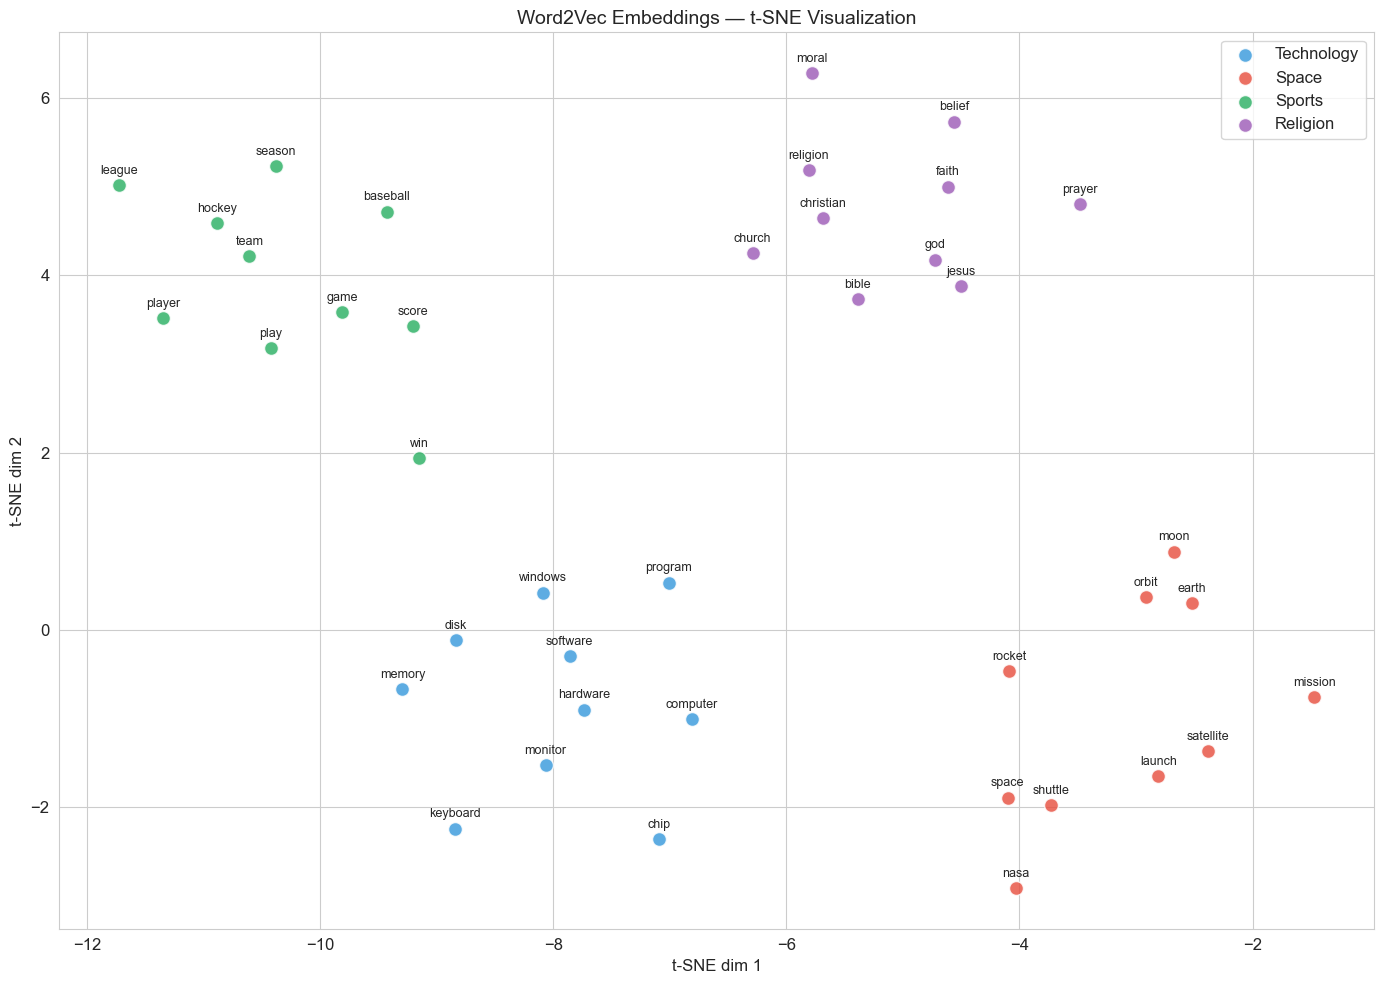

In [29]:
# --- Visualize embeddings with t-SNE ---
from sklearn.manifold import TSNE

# Select words from different topics
topic_words = {
    'Technology': ['computer', 'software', 'hardware', 'program', 'windows',
                   'disk', 'memory', 'chip', 'keyboard', 'monitor'],
    'Space': ['space', 'nasa', 'orbit', 'launch', 'shuttle',
              'satellite', 'moon', 'earth', 'mission', 'rocket'],
    'Sports': ['hockey', 'baseball', 'game', 'team', 'player',
               'score', 'season', 'league', 'win', 'play'],
    'Religion': ['god', 'church', 'christian', 'bible', 'faith',
                 'jesus', 'belief', 'religion', 'moral', 'prayer'],
}

# Filter words that exist in vocabulary
all_words = []
all_labels = []
all_vectors = []

for topic, words in topic_words.items():
    for w in words:
        if w in w2v_model.wv:
            all_words.append(w)
            all_labels.append(topic)
            all_vectors.append(w2v_model.wv[w])

vectors_matrix = np.array(all_vectors)
print(f'Words found in vocabulary: {len(all_words)} / {sum(len(v) for v in topic_words.values())}')

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(all_words)-1))
coords = tsne.fit_transform(vectors_matrix)

# Plot
plt.figure(figsize=(14, 10))
colors_map = {'Technology': '#3498db', 'Space': '#e74c3c',
              'Sports': '#27ae60', 'Religion': '#9b59b6'}

for topic in topic_words.keys():
    mask = [l == topic for l in all_labels]
    xs = coords[mask, 0]
    ys = coords[mask, 1]
    plt.scatter(xs, ys, c=colors_map[topic], label=topic, s=100, alpha=0.8, edgecolors='white')

for i, word in enumerate(all_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]),
                 fontsize=9, ha='center', va='bottom',
                 xytext=(0, 6), textcoords='offset points')

plt.legend(fontsize=12, loc='best')
plt.title('Word2Vec Embeddings — t-SNE Visualization', fontsize=14)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

---

## 7. Comparing Classical Methods

### 7.1 Document Vectors from Word2Vec

Word2Vec gives us **word-level** vectors. To classify documents, we need **document-level** vectors.

A simple approach is to average the word vectors:

$$\vec{d} = \frac{1}{|d|} \sum_{w \in d} \vec{v}_w$$

where $|d|$ is the number of words in document $d$ that are in the vocabulary.

A weighted variant uses **TF-IDF weights**:

$$\vec{d} = \frac{\sum_{w \in d} \text{tfidf}(w, d) \cdot \vec{v}_w}{\sum_{w \in d} \text{tfidf}(w, d)}$$

### 7.2 Comparison Plan

We compare these representations with the same classifier (Logistic Regression):

| Method | Representation | Dimensionality |
|--------|----------------|----------------|
| **BoW** | Raw word counts | 10,000 (sparse) |
| **TF-IDF** | Weighted word counts | 10,000 (sparse) |
| **Word2Vec (avg)** | Mean word embeddings | 150 (dense) |

In [30]:
# --- Build document vectors from Word2Vec ---

def document_vector(doc_text, model, use_tfidf_weights=False, tfidf_vocab=None, tfidf_idf=None):
    """Compute a document vector by averaging Word2Vec word vectors."""
    tokens = simple_preprocess(doc_text, deacc=True, min_len=2)
    vectors = []
    weights = []

    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
            if use_tfidf_weights and tfidf_vocab is not None and token in tfidf_vocab:
                idx = tfidf_vocab[token]
                weights.append(tfidf_idf[idx])
            else:
                weights.append(1.0)

    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)

    vectors = np.array(vectors)
    weights = np.array(weights)
    return np.average(vectors, axis=0, weights=weights)


# Compute document vectors for train and test
print('Computing document vectors (this may take a moment)...')
X_train_w2v = np.array([document_vector(doc, w2v_model) for doc in newsgroups_train.data])
X_test_w2v = np.array([document_vector(doc, w2v_model) for doc in newsgroups_test.data])

print(f'W2V document vectors shape (train): {X_train_w2v.shape}')
print(f'W2V document vectors shape (test):  {X_test_w2v.shape}')

Computing document vectors (this may take a moment)...
W2V document vectors shape (train): (11314, 150)
W2V document vectors shape (test):  (7532, 150)


In [31]:
# --- Compare all methods ---
from sklearn.preprocessing import StandardScaler

# Normalize W2V features
scaler = StandardScaler()
X_train_w2v_scaled = scaler.fit_transform(X_train_w2v)
X_test_w2v_scaled = scaler.transform(X_test_w2v)

methods = {
    'BoW + LogReg': (X_train_bow, X_test_bow),
    'TF-IDF + LogReg': (X_train_tfidf, X_test_tfidf),
    'Word2Vec (avg) + LogReg': (X_train_w2v_scaled, X_test_w2v_scaled),
}

comparison_results = {}

for name, (X_tr, X_te) in methods.items():
    clf = LogisticRegression(max_iter=1000, C=5, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    comparison_results[name] = {'Accuracy': acc, 'F1 (weighted)': f1}
    print(f'{name:30s} — Accuracy: {acc:.4f}  F1: {f1:.4f}')

comparison_df = pd.DataFrame(comparison_results).T
comparison_df

BoW + LogReg                   — Accuracy: 0.5916  F1: 0.5931
TF-IDF + LogReg                — Accuracy: 0.6723  F1: 0.6718
Word2Vec (avg) + LogReg        — Accuracy: 0.6093  F1: 0.6096


,Accuracy,F1 (weighted)
BoW + LogReg,0.591609,0.593146
TF-IDF + LogReg,0.672331,0.671770
Word2Vec (avg) + LogReg,0.609267,0.609557


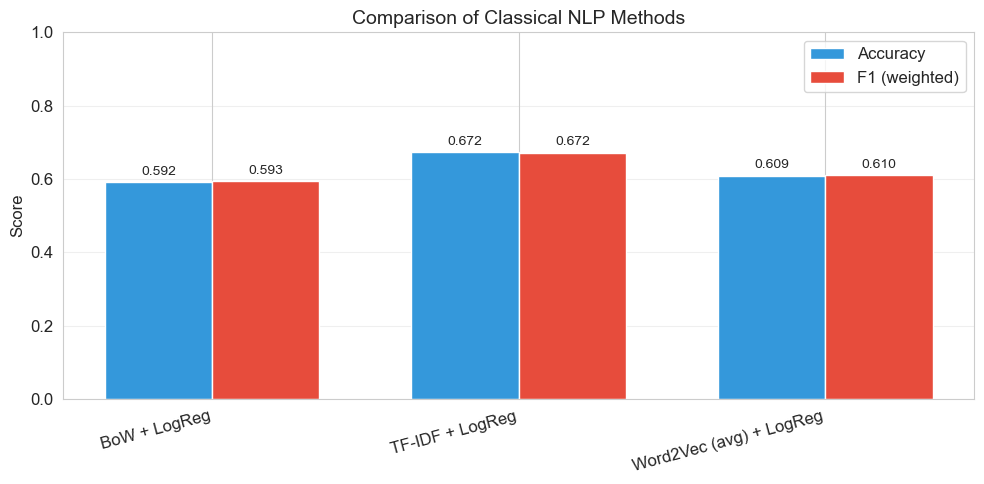

In [32]:
# --- Visualization of comparison ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width,
               label='Accuracy', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison_df['F1 (weighted)'], width,
               label='F1 (weighted)', color='#e74c3c', edgecolor='white')

ax.set_ylabel('Score')
ax.set_title('Comparison of Classical NLP Methods', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---

## 8. Impact of Hyperparameters

### 8.1 TF-IDF: Effect of `max_features`

The `max_features` parameter controls vocabulary size. Let's see how it affects classification performance.

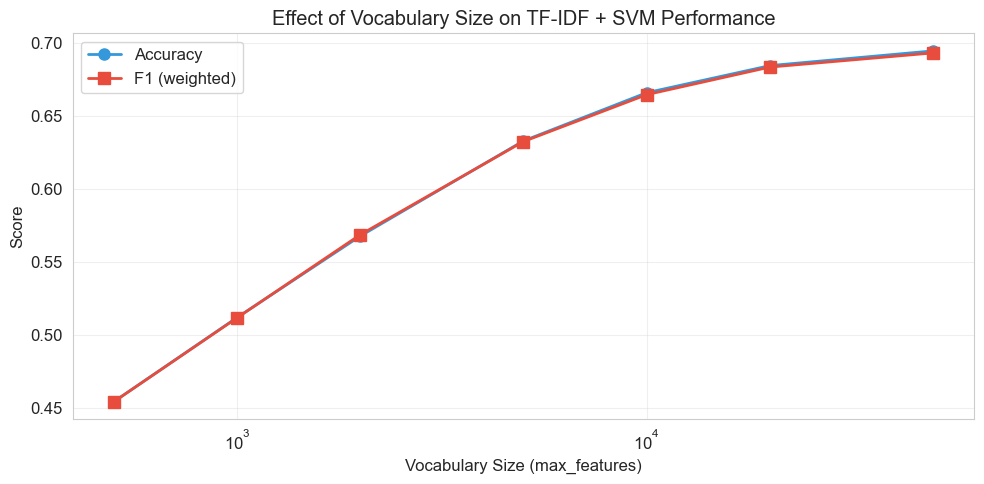

,max_features,Accuracy,F1
0,500,0.453930,0.453946
1,1000,0.511683,0.511484
2,2000,0.567578,0.568529
3,5000,0.632767,0.632340
4,10000,0.665826,0.664496
5,20000,0.684413,0.683416
6,50000,0.694503,0.693107


In [33]:
# --- Effect of vocabulary size on TF-IDF ---
vocab_sizes = [500, 1000, 2000, 5000, 10000, 20000, 50000]
vocab_results = []

for n_features in vocab_sizes:
    vec = TfidfVectorizer(max_features=n_features, stop_words='english',
                          sublinear_tf=True)
    X_tr = vec.fit_transform(newsgroups_train.data)
    X_te = vec.transform(newsgroups_test.data)

    clf = LinearSVC(C=1.0, max_iter=2000, random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    vocab_results.append({'max_features': n_features, 'Accuracy': acc, 'F1': f1})

vocab_df = pd.DataFrame(vocab_results)

plt.figure(figsize=(10, 5))
plt.plot(vocab_df['max_features'], vocab_df['Accuracy'], 'o-',
         label='Accuracy', color='#3498db', linewidth=2, markersize=8)
plt.plot(vocab_df['max_features'], vocab_df['F1'], 's-',
         label='F1 (weighted)', color='#e74c3c', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Vocabulary Size (max_features)')
plt.ylabel('Score')
plt.title('Effect of Vocabulary Size on TF-IDF + SVM Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

vocab_df

### 8.2 Word2Vec: Effect of Embedding Dimension

Let's compare different `vector_size` values for Word2Vec.

Training Word2Vec with vector_size=50...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training Word2Vec with vector_size=100...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training Word2Vec with vector_size=150...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training Word2Vec with vector_size=200...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Training Word2Vec with vector_size=300...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


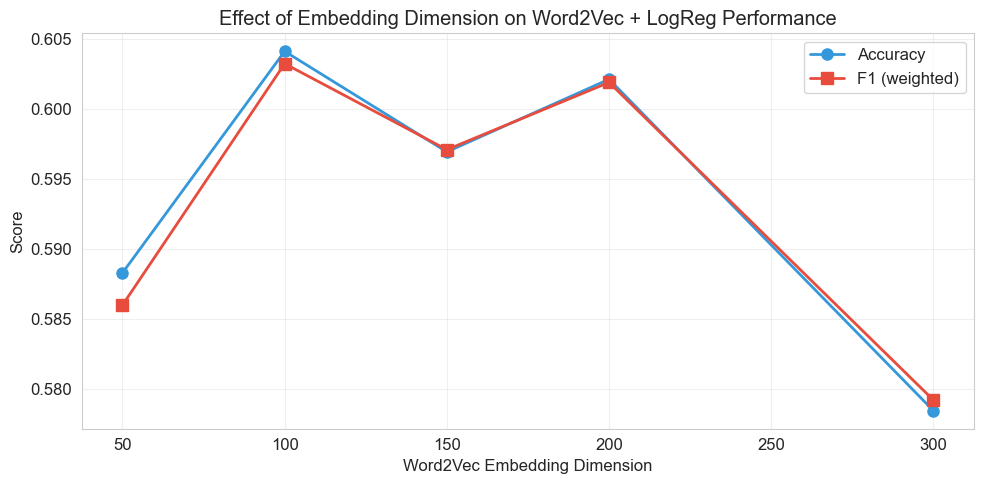

,vector_size,Accuracy,F1
0,50,0.588290,0.585994
1,100,0.604089,0.603208
2,150,0.596920,0.597077
3,200,0.602098,0.601872
4,300,0.578465,0.579224


In [34]:
# --- Effect of embedding dimension ---
embed_dims = [50, 100, 150, 200, 300]
dim_results = []

for dim in embed_dims:
    print(f'Training Word2Vec with vector_size={dim}...')
    model_temp = Word2Vec(
        sentences=corpus_w2v, vector_size=dim, window=5,
        min_count=3, sg=1, negative=10, epochs=15,
        workers=4, seed=42
    )

    # Build document vectors
    X_tr_temp = np.array([document_vector(doc, model_temp) for doc in newsgroups_train.data])
    X_te_temp = np.array([document_vector(doc, model_temp) for doc in newsgroups_test.data])

    scaler_temp = StandardScaler()
    X_tr_temp = scaler_temp.fit_transform(X_tr_temp)
    X_te_temp = scaler_temp.transform(X_te_temp)

    clf = LogisticRegression(max_iter=1000, C=5, random_state=42)
    clf.fit(X_tr_temp, y_train)
    y_pred = clf.predict(X_te_temp)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    dim_results.append({'vector_size': dim, 'Accuracy': acc, 'F1': f1})

dim_df = pd.DataFrame(dim_results)

plt.figure(figsize=(10, 5))
plt.plot(dim_df['vector_size'], dim_df['Accuracy'], 'o-',
         label='Accuracy', color='#3498db', linewidth=2, markersize=8)
plt.plot(dim_df['vector_size'], dim_df['F1'], 's-',
         label='F1 (weighted)', color='#e74c3c', linewidth=2, markersize=8)
plt.xlabel('Word2Vec Embedding Dimension')
plt.ylabel('Score')
plt.title('Effect of Embedding Dimension on Word2Vec + LogReg Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dim_df

---

## 9. Summary and Key Takeaways

### What We Learned

| Step | Key Insight |
|------|-------------|
| **Preprocessing** | Cleaning, tokenization, and stopword removal significantly impact downstream tasks |
| **BoW** | Simple but effective baseline; ignores word order and semantics |
| **TF-IDF** | Outperforms raw BoW by down-weighting common words |
| **Word2Vec** | Captures semantic relationships but averaging loses document-level information |
| **Classification** | TF-IDF + Linear SVM is a strong baseline for text classification |
| **Hyperparameters** | Vocabulary size and embedding dimension both affect performance |

### Classical Methods vs. Modern Approaches

| Aspect | Classical (BoW/TF-IDF) | Embeddings (Word2Vec) | Modern (BERT, LLMs) |
|--------|------------------------|----------------------|---------------------|
| **Representation** | Sparse, high-dim | Dense, low-dim | Dense, contextual |
| **Semantics** | No / partial | Static | Contextual |
| **Word order** | Ignored | Local context | Full sequence |
| **Training data** | Task-specific | Unlabeled corpus | Massive pretraining |
| **Compute** | Very low | Low | High (GPU) |
| **Performance** | Good baseline | Moderate | State-of-the-art |

### Looking Ahead

In **Part 2**, we will move from static representations to **contextual embeddings** (RNNs, Transformers), where the same word receives different vectors depending on its context — addressing the main limitation of the methods we explored today.

---

## 10. Exercises (Optional)

Try these on your own to deepen your understanding:

1. **Preprocessing ablation:** Repeat classification without stopword removal. Does it help or hurt?

2. **N-grams:** Use `ngram_range=(1, 2)` in `TfidfVectorizer` to include bigrams. Does it improve performance?

3. **CBOW vs. Skip-gram:** Train a Word2Vec model with `sg=0` (CBOW) and compare with Skip-gram.

4. **TF-IDF weighted W2V:** Use the `use_tfidf_weights=True` option in `document_vector()` to compute TF-IDF-weighted document vectors. Does it help?

5. **Subset classification:** Restrict to 4-5 categories and observe if simpler problems lead to higher accuracy.

6. **Error analysis:** For the worst-performing categories, examine misclassified documents. What makes them hard to classify?

In [35]:
# Space for your experiments
